In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import re
import json
from sklearn.preprocessing import MinMaxScaler
from math import pi
from datetime import timedelta

from Tools import Tools4DataExtraction as T4DE

In [2]:
D4NN= T4DE.Get_Data4NN_p()
atributo='FECHA_CORRIDA'
D4NN[atributo] = pd.to_datetime(D4NN[atributo])
fecha_maxima = D4NN[atributo].max()
dia_anterior = fecha_maxima - timedelta(days=1)
"""
fecha_inicio = dia_anterior - timedelta(days=364)
D4NN = D4NN[(D4NN[atributo] >= fecha_inicio) &
                    (D4NN[atributo] <= dia_anterior)].copy()
"""
D4NN = D4NN[(D4NN[atributo] <= dia_anterior)].copy()


Memoria usada antes: 628.36 MB
Memoria usada después: 122.08 MB
Reducción: 80.6%


In [3]:
D4NN.columns

Index(['OPERACION', 'TRANSACCION', 'FECHA_OPERACION', 'HORA_OPERACION',
       'NOMBRE_DIA_OPERACION', 'AREA_VENTA', 'CLASE_SERVICIO', 'ORIGEN',
       'DESTINO', 'CV_CORRIDA', 'FECHA_CORRIDA', 'HORA_SALIDA_CORRIDA',
       'TIPO_PASAJERO', 'TIPO_CLIENTE', 'TIPO_OPERACION', 'VENTA_ANTICIPADA',
       'NOMBRE_PASAJERO', 'NUM_ASIENTO', 'PORCENT_PROMO', 'DESC_DESCUENTO',
       'BOLETOS_CANCEL', 'BOLETOS_TOTALES', 'BOLETOS_VEND', 'VENTA_CANCEL',
       'IVA_CANCEL', 'IVA_VENDIDO', 'VENTA_TOTAL', 'VENTA', 'CV_ASIGN',
       'ORIGEN_CORRIDA', 'DESTINO_CORRIDA', 'CAPACIDAD_ASIENTOS_TRAMO',
       'KMS_TRAMO', 'EMPRESA', 'TIPO_CORRIDA', 'TIPO_BUS',
       'HORA_SALIDA_ORIGEN_CORRIDA', 'KMS_ACUM_CORRIDA', 'NOMBRE_DIA_CORRIDA',
       'TARIFA_BASE_TRAMO', 'IVA_TARIFA_BASE_TRAMO', 'INGRESO_TRANSP',
       'IVA_TRANSP', 'DISPONIBILIDAD_TRAMO', 'OCUPACION_TRAMO', 'PAX_BAJAN',
       'PAX_SUBEN', 'TARJETA', 'EFECTIVO', 'EMAIL', 'PAGO_METODO',
       'TOTAL_BOLETOS', 'TOTAL_VENTA', 'DIF_TARIF', 'HOR

In [5]:
#D4NN.to_csv("DatosCrudo4NN.csv")

In [6]:
# ---------------------------------------------------------
# 1. Filtrar columnas numéricas del DataFrame original
# ---------------------------------------------------------
df_num = D4NN.select_dtypes(include=['number'])

# ---------------------------------------------------------
# 2. Agregar la columna FECHA_CORRIDA (si no es índice)
# ---------------------------------------------------------
# Asegúrate de tener FECHA_CORRIDA en el DataFrame principal
df_num['FECHA_CORRIDA'] = D4NN['FECHA_CORRIDA']

# ---------------------------------------------------------
# 3. Agrupar por fecha y sumar variables numéricas
# ---------------------------------------------------------
agg_dict = {col: 'mean' for col in df_num.columns if col not in ['BOLETOS_VEND', 'FECHA_CORRIDA']}
agg_dict['BOLETOS_VEND'] = 'sum'

df_group = df_num.groupby('FECHA_CORRIDA').agg(agg_dict).reset_index()

df_group=df_group.drop(['BOLETOS_CANCEL','BOLETOS_TOTALES', 'IVA_CANCEL','TOTAL_BOLETOS','VENTA_CANCEL','PAX_BAJAN',
                       'IVA_TARIFA_BASE_TRAMO','IVA_TRANSP','DIAS_ANTICIPACION','TIEMPO_ANTICIPACION','VENTA_TOTAL',
                       'TOTAL_VENTA','KMS_ACUM_CORRIDA'],axis=1)

# ---------------------------------------------------------
# 4. Calcular correlación con la variable BOLETOS_VEND
# ---------------------------------------------------------
# (Asegúrate de que BOLETOS_VEND exista en las columnas)
correlaciones = df_group.corr()['BOLETOS_VEND'].sort_values(ascending=False)

# ---------------------------------------------------------
# 5. Mostrar resultados ordenados
# ---------------------------------------------------------
print("📊 Correlación de cada variable numérica con BOLETOS_VEND:\n")
print(correlaciones)

df_2Corr=df_group.drop(['FECHA_CORRIDA','BOLETOS_VEND'],axis=1)

📊 Correlación de cada variable numérica con BOLETOS_VEND:

BOLETOS_VEND                1.000000
PAX_SUBEN                   0.601222
HORAS_ANTICIPACION          0.486040
INGRESO_TRANSP              0.446121
OCUPACION_TRAMO             0.343786
NUM_ASIENTO                 0.225305
MES                         0.105607
PORCENT_PROMO               0.077074
HORA_DECIMAL                0.074968
KMS_TRAMO                   0.001692
DIF_TARIF                  -0.048280
TARIFA_BASE_TRAMO          -0.079854
VENTA                      -0.094694
IVA_VENDIDO                -0.094704
FECHA_CORRIDA              -0.200004
CAPACIDAD_ASIENTOS_TRAMO   -0.241904
AÑO                        -0.242922
DISPONIBILIDAD_TRAMO       -0.623269
Name: BOLETOS_VEND, dtype: float64


In [7]:
df_group

,FECHA_CORRIDA,NUM_ASIENTO,PORCENT_PROMO,IVA_VENDIDO,VENTA,CAPACIDAD_ASIENTOS_TRAMO,KMS_TRAMO,TARIFA_BASE_TRAMO,INGRESO_TRANSP,DISPONIBILIDAD_TRAMO,OCUPACION_TRAMO,PAX_SUBEN,DIF_TARIF,HORA_DECIMAL,AÑO,MES,HORAS_ANTICIPACION,BOLETOS_VEND
0,2023-01-01,15.239521,10.714286,130.957901,818.473511,28.544910,520.0,978.450012,20037.644551,3.970060,23.976048,24.574850,0.702678,18.820359,2023.0,1.0,4.526946,167.0
1,2023-01-02,16.399142,10.194175,138.478668,865.482727,32.841202,520.0,978.450012,21673.270215,6.733906,22.489271,26.107296,0.743035,13.356223,2023.0,1.0,12.369099,233.0
2,2023-01-03,17.722222,10.877863,134.098495,838.102966,33.084362,520.0,978.450012,22770.668889,4.895062,24.823046,28.084362,0.719514,15.699588,2023.0,1.0,16.901235,486.0
3,2023-01-04,18.276596,10.199005,131.993134,824.945251,35.000000,520.0,978.450012,22756.790064,6.576596,24.810638,28.423404,0.708217,15.289362,2023.0,1.0,14.161702,470.0
4,2023-01-05,16.411348,10.185185,123.139076,769.602783,34.829787,520.0,978.450012,13295.498085,17.397163,15.191489,17.432624,0.660707,15.414894,2023.0,1.0,14.641844,282.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1033,2025-10-30,16.213115,3.986486,166.304428,1039.400513,36.000000,520.0,1163.790039,29908.798197,7.918033,25.131147,28.081967,0.750238,11.524590,2025.0,10.0,45.901639,122.0
1034,2025-10-31,16.166667,4.148936,163.670975,1022.934875,36.000000,520.0,1163.790039,20836.667353,15.960784,14.215686,20.039216,0.738329,11.343137,2025.0,10.0,53.911765,102.0
1035,2025-11-01,15.542857,3.392857,164.045151,1025.277710,36.000000,520.0,1163.790039,12712.077429,23.771429,11.971429,12.228571,0.740021,15.257143,2025.0,11.0,125.528571,70.0
1036,2025-11-02,16.782609,4.352941,176.100876,1100.624512,35.956522,520.0,1163.790039,27425.096957,10.101449,23.376812,25.855072,0.794399,14.217391,2025.0,11.0,110.391304,138.0


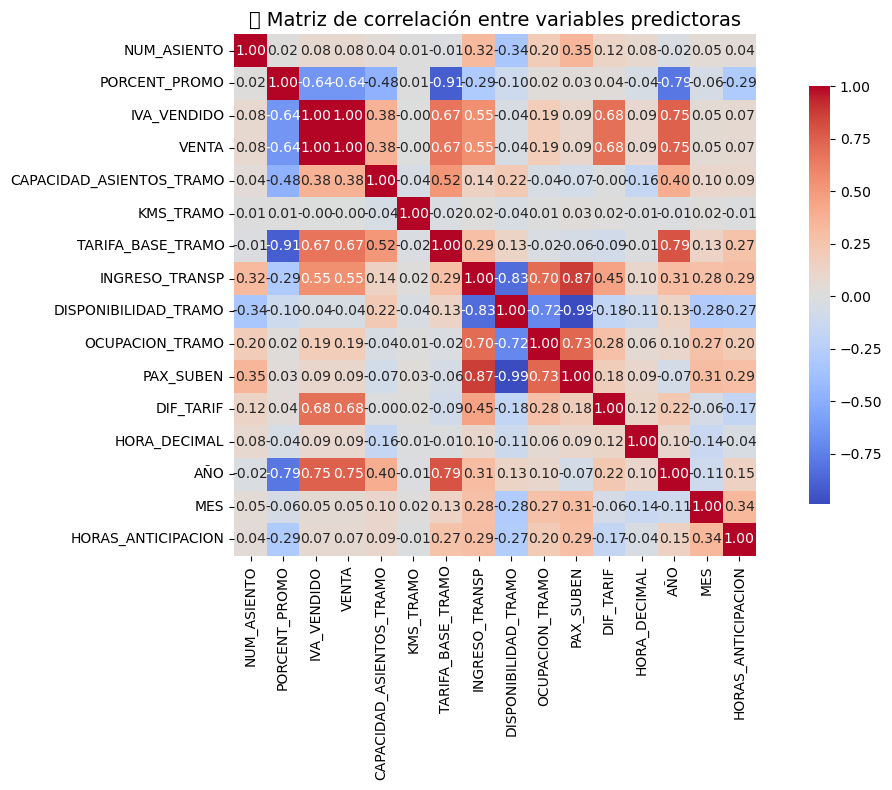


🔁 Pares de variables con alta correlación entre sí (>|0.7|):

               Variable_1            Variable_2  Correlación
35            IVA_VENDIDO                 VENTA     1.000000
122        INGRESO_TRANSP             PAX_SUBEN     0.873806
120        INGRESO_TRANSP  DISPONIBILIDAD_TRAMO    -0.833543
22          PORCENT_PROMO     TARIFA_BASE_TRAMO    -0.905204
138  DISPONIBILIDAD_TRAMO             PAX_SUBEN    -0.988872


In [8]:
# ---------------------------------------------------------
# 6. Calcular matriz de correlación entre predictores
# ---------------------------------------------------------
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

corr_matrix = df_2Corr.corr()

# ---------------------------------------------------------
# 7. Visualizar matriz de correlaciones (heatmap)
# ---------------------------------------------------------
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("🔍 Matriz de correlación entre variables predictoras", fontsize=14)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 8. Identificar pares de variables altamente correlacionadas
# ---------------------------------------------------------
threshold = 0.8  # umbral para considerar alta correlación

# Convertir la matriz en una tabla de pares (variable1, variable2, correlación)
corr_pairs = (
    corr_matrix.unstack()
    .reset_index()
    .rename(columns={'level_0': 'Variable_1', 'level_1': 'Variable_2', 0: 'Correlación'})
)

# Filtrar solo los pares distintos y con correlación alta
corr_pairs = corr_pairs[
    (corr_pairs['Variable_1'] != corr_pairs['Variable_2']) &
    (corr_pairs['Correlación'].abs() > threshold)
]

# Eliminar duplicados (para no tener A-B y B-A)
corr_pairs = corr_pairs.drop_duplicates(subset=['Correlación'])

# ---------------------------------------------------------
# 9. Mostrar resultados
# ---------------------------------------------------------
print("\n🔁 Pares de variables con alta correlación entre sí (>|0.7|):\n")
print(corr_pairs.sort_values(by='Correlación', ascending=False))

In [9]:
# ---------------------------------------------------------
# 🔟 Detección y eliminación automática de variables colineales
# ---------------------------------------------------------
import numpy as np

# Calcular matriz de correlación
corr_matrix = df_2Corr.corr().abs()

# Crear un vector booleano para marcar las variables a conservar
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Umbral de correlación alta (ajustable)
threshold = 0.8

# Identificar las columnas a eliminar
to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

# ---------------------------------------------------------
# 11. Crear lista final de variables no colineales
# ---------------------------------------------------------
final_features = [col for col in df_2Corr.columns if col not in to_drop]

print("✅ Variables eliminadas por alta colinealidad (>|0.8|):\n")
print(to_drop)
print("\n📋 Lista final de variables sin colinealidad:\n")
print(final_features)


✅ Variables eliminadas por alta colinealidad (>|0.8|):

['VENTA', 'TARIFA_BASE_TRAMO', 'DISPONIBILIDAD_TRAMO', 'PAX_SUBEN']

📋 Lista final de variables sin colinealidad:

['NUM_ASIENTO', 'PORCENT_PROMO', 'IVA_VENDIDO', 'CAPACIDAD_ASIENTOS_TRAMO', 'KMS_TRAMO', 'INGRESO_TRANSP', 'OCUPACION_TRAMO', 'DIF_TARIF', 'HORA_DECIMAL', 'AÑO', 'MES', 'HORAS_ANTICIPACION']
